# Validate Lightweight LightGBM Model (Top 100 Features)
This notebook evaluates your custom Lightweight EMBER model which was trained on only the top 100 features. It will slice the test dataset to exactly those 100 features, predict the outcomes, and visualize the performance.

The goal is to prove that removing >95% of the data (noise) maintained (or even improved) real-world accuracy.

In [1]:
import os
import sys
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, precision_score, recall_score, f1_score

# Display plots inline
%matplotlib inline

# Ensure the paths to the virtual environment(s) are added BEFORE importing packages
base_dir = os.getcwd()
for venv_folder in ["venv", ".venv"]:
    site_packages = os.path.join(base_dir, venv_folder, "Lib", "site-packages")
    if os.path.exists(site_packages) and site_packages not in sys.path:
        sys.path.insert(0, site_packages)
        break

global_venv_site_packages = r"Z:\ai project\.venv\Lib\site-packages"
if os.path.exists(global_venv_site_packages) and global_venv_site_packages not in sys.path:
    sys.path.insert(0, global_venv_site_packages)

try:
    from thrember.features import PEFeatureExtractor
    print("Features extractor imported successfully.")
except ImportError:
    print("Warning: 'thrember' not found. Will use default feature dimension (2381).")
    class PEFeatureExtractor:
        dim = 2381

Z:\ai project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features extractor imported successfully.


### 1. Setup Dataset & Configuration
Here we load the required indices array in addition to figuring out our data boundaries.

In [2]:
def setup_dataset(dataset_dir, model_filename="ember_model_reduced_100.txt", indices_filename="ember_reduced_100_indices.npy"):
    print(f"Preparing to evaluate lightweight model from {dataset_dir}...")
    
    model_path = os.path.join(dataset_dir, model_filename)
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Error: Model file not found at {model_path}")

    indices_path = os.path.join(dataset_dir, indices_filename)
    if not os.path.exists(indices_path):
        raise FileNotFoundError(f"Error: Indices file not found at {indices_path}. The model won't know which features to use!")
        
    # Load top 100 indices
    top_100_indices = np.load(indices_path)

    # Setup paths
    X_path = os.path.join(dataset_dir, "X_train.dat")  # Because test set is the last 10%
    y_path = os.path.join(dataset_dir, "y_train.dat")
    plots_dir = os.path.join(dataset_dir, "evaluation_plots_reduced")
    os.makedirs(plots_dir, exist_ok=True)
    
    # Get dimensions
    extractor = PEFeatureExtractor()
    ndim = extractor.dim
    
    if not os.path.exists(X_path):
         raise FileNotFoundError(f"Error: Data file not found at {X_path}")
         
    file_size = os.path.getsize(X_path)
    nrows = file_size // (ndim * 4)
    
    # Calculate Split (Last 10% is test)
    train_nrows = int(nrows * 0.9)
    val_nrows = nrows - train_nrows
    val_start_idx = train_nrows
    
    print(f"Loaded Top {len(top_100_indices)} Indices for lightweight evaluation.")
    print(f"Test set size: {val_nrows} samples (starts at index {val_start_idx})")
    
    return model_path, top_100_indices, plots_dir, X_path, y_path, nrows, ndim, val_start_idx, val_nrows

### 2. Batched Prediction Loop (With Slice)

In [3]:
def run_predictions(model_path, top_100_indices, X_path, y_path, nrows, ndim, val_start_idx, val_nrows, batch_size=100000):
    print(f"\nLoading lightweight model: {model_path}...")
    model = lgb.Booster(model_file=model_path)

    # Memory map the arrays
    X_memmap = np.memmap(X_path, dtype=np.float32, mode="r", shape=(nrows, ndim))
    y_memmap = np.memmap(y_path, dtype=np.int32, mode="r", shape=(nrows,))

    print(f"Starting prediction loop...")
    
    y_true_all = []
    y_pred_prob_all = []

    for batch_start in range(val_start_idx, nrows, batch_size):
        batch_end = min(batch_start + batch_size, nrows)
        
        # EXACT SAME SLICE AS TRAINING: Load batch, but instantly pull only the 100 features
        X_batch = np.array(X_memmap[batch_start:batch_end][:, top_100_indices])
        y_batch = np.array(y_memmap[batch_start:batch_end])
        
        # Filter unlabeled records (-1)
        valid_mask = y_batch != -1
        if not np.any(valid_mask):
            continue
            
        X_batch = X_batch[valid_mask]
        y_batch = y_batch[valid_mask]
        
        # Predict probabilities
        preds = model.predict(X_batch)
        
        y_true_all.extend(y_batch)
        y_pred_prob_all.extend(preds)
        
        print(f"  Processed batch {batch_start} - {batch_end} using 100 features")

    y_true = np.array(y_true_all)
    y_pred_probs = np.array(y_pred_prob_all)
    
    return model, y_true, y_pred_probs

### 3. Metric Calculations & Visualizations

In [4]:
def evaluate_and_plot(model, y_val, y_pred_prob, plots_dir, feature_names=None):
    if len(y_val) == 0:
        print("Error: No valid labels found to evaluate.")
        return
        
    y_pred = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val, y_pred_prob)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print("-" * 40)
    print(f"🚀 LIGHTWEIGHT TEST RESULTS 🚀")
    print("-" * 40)
    print(f"Test AUC:       {auc:.4f}")
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall:    {rec:.4f}")
    print(f"Test F1 Score:  {f1:.4f}")
    print("-" * 40)

    # 1. ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'LightGBM Reduced (AUC = {auc:.4f})', linewidth=2, color='darkgreen')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Lightweight Model)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    
    roc_save_path = os.path.join(plots_dir, 'roc_curve_reduced.png')
    plt.savefig(roc_save_path)
    plt.show() 

    # 2. Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Benign', 'Malicious'], 
                yticklabels=['Benign', 'Malicious'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Lightweight Model)')
    
    cm_save_path = os.path.join(plots_dir, 'confusion_matrix_reduced.png')
    plt.savefig(cm_save_path)
    plt.show()

    # 3. Feature Importance (Custom bar plot mapped to human-readable names)
    importances = model.feature_importance(importance_type='gain')
    plt.figure(figsize=(10, 8))

    if feature_names is not None and len(feature_names) == len(importances):
        # We have mapped string names! Plot a nice horizontal bar chart
        top_indices = np.argsort(importances)[-25:] # Ascending (bottom to top display)
        
        plt.barh(np.arange(len(top_indices)), importances[top_indices], color='teal')
        plt.yticks(np.arange(len(top_indices)), [feature_names[i] for i in top_indices])
        plt.xlabel('Feature Importance (Gain)')
        plt.title('Top 25 Important Features (By Actual Name)')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        
        fi_save_path = os.path.join(plots_dir, 'feature_importance_reduced.png')
        plt.savefig(fi_save_path)
        plt.show()
    else:
        # Fallback to LightGBM's default numerical column index plotter
        ax = lgb.plot_importance(model, max_num_features=25, title='Top 25 Feature Importances', 
                                 importance_type='gain', figsize=(10, 8))
        plt.tight_layout()
        
        fi_save_path = os.path.join(plots_dir, 'feature_importance_reduced.png')
        plt.savefig(fi_save_path)
        plt.show()

### 4. Run Evaluation Pipeline

Preparing to evaluate lightweight model from Z:\ember2024_train_data...


Loaded Top 100 Indices for lightweight evaluation.
Test set size: 525200 samples (starts at index 4726800)

Loading lightweight model: Z:\ember2024_train_data\ember_model_reduced_100.txt...
Starting prediction loop...
  Processed batch 4726800 - 4826800 using 100 features
  Processed batch 4826800 - 4926800 using 100 features
  Processed batch 4926800 - 5026800 using 100 features
  Processed batch 5026800 - 5126800 using 100 features
  Processed batch 5126800 - 5226800 using 100 features
  Processed batch 5226800 - 5252000 using 100 features
----------------------------------------
🚀 LIGHTWEIGHT TEST RESULTS 🚀
----------------------------------------
Test AUC:       0.9940
Test Accuracy:  0.9616
Test Precision: 0.9711
Test Recall:    0.9515
Test F1 Score:  0.9612
----------------------------------------


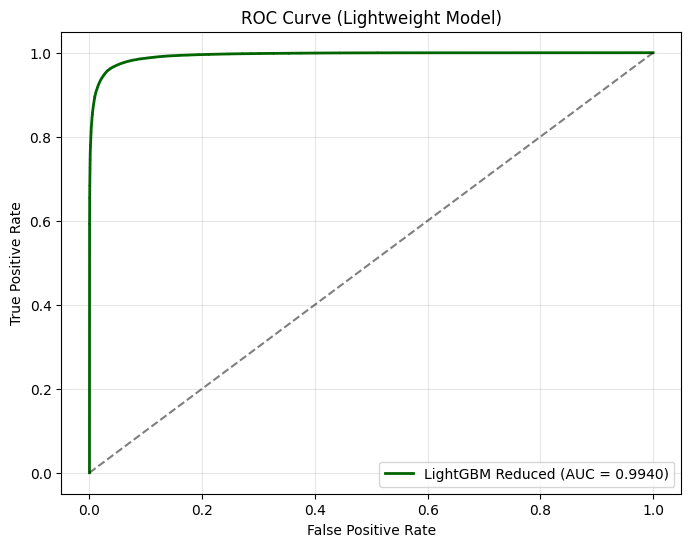

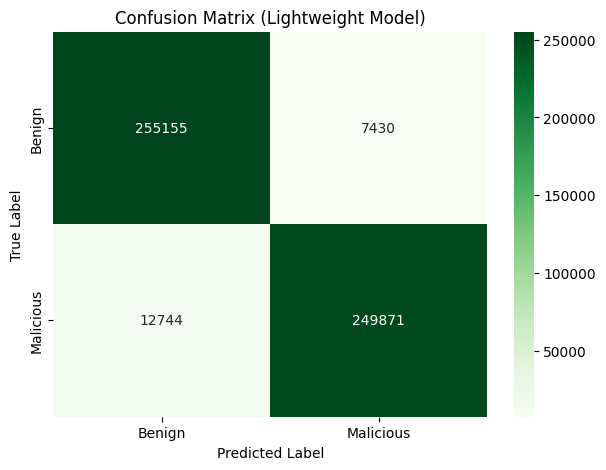

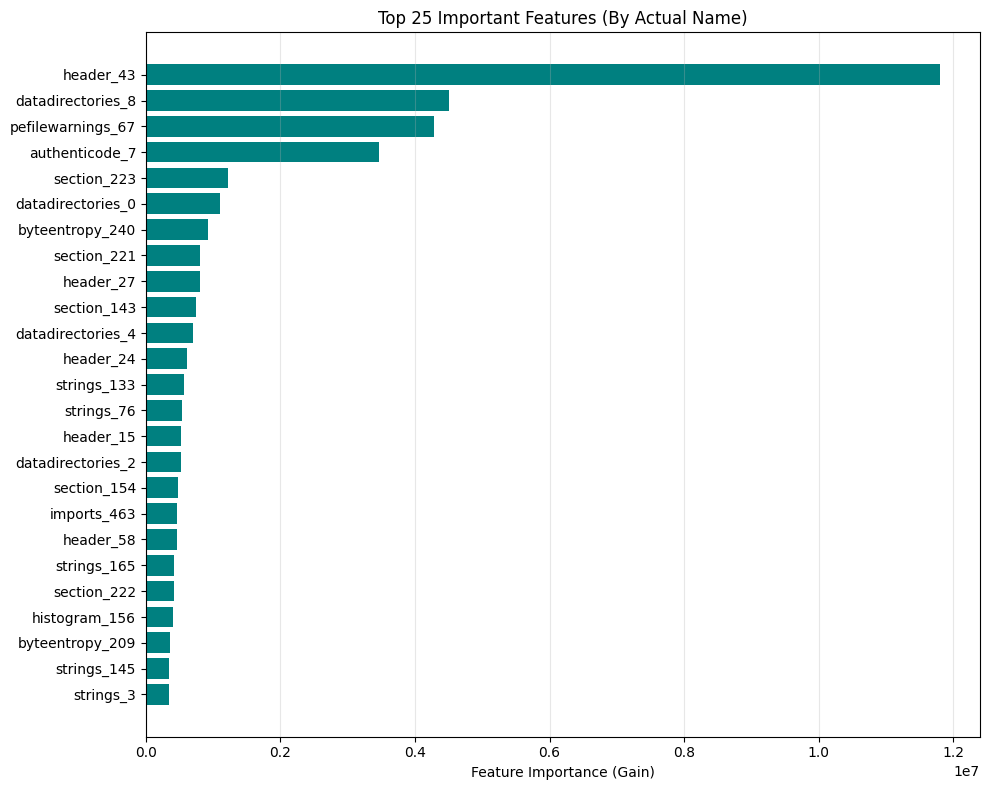


=> ✅ Reduced Evaluation pipeline complete.


In [5]:
DATASET_DIR = r"Z:\ember2024_train_data"
MODEL_FILENAME = "ember_model_reduced_100.txt"
INDICES_FILENAME = "ember_reduced_100_indices.npy"

try:
    # 0. Setup actual feature names (by mapping the indices to Thrember PE block definitions)
    try:
        from thrember.features import PEFeatureExtractor
        extractor = PEFeatureExtractor()
        full_feature_names = []
        for block in extractor.features:
            for i in range(block.dim):
                full_feature_names.append(f"{block.name}_{i}")
    except Exception:
        print("Warning: Thrember not found. Will just guess placeholder names.")
        full_feature_names = [f"Feature_{i}" for i in range(2381)]

    # 1. Setup paths
    model_path, top_100_indices, plots_dir, X_path, y_path, nrows, ndim, val_start, val_nrows = setup_dataset(
        dataset_dir=DATASET_DIR, 
        model_filename=MODEL_FILENAME,
        indices_filename=INDICES_FILENAME
    )
    
    # Map the top 100 array indices to their actual real-world names
    reduced_feature_names = [full_feature_names[i] for i in top_100_indices]
    
    # 2. Iterate and Predict
    model_obj, y_val, y_pred_prob = run_predictions(
        model_path, top_100_indices, X_path, y_path, nrows, ndim, val_start, val_nrows, batch_size=100000
    )
    
    # 3. Grade & Visualize (Now passing in the fully readable names!)
    evaluate_and_plot(model_obj, y_val, y_pred_prob, plots_dir, feature_names=reduced_feature_names)
    
    print("\n=> ✅ Reduced Evaluation pipeline complete.")
    
except FileNotFoundError as e:
    print(e)